# ⚙️ 실습 3: Non-Convex 최적화 기법 실험
> **AI Programming Course** — Konan Technology

---

## 학습 목표
- Non-Convex Loss 지형에서 발생하는 문제(Saddle Point, Vanishing Gradient 등)를 이해한다
- Momentum, Adam, LR Scheduler, Gradient Clipping, SWA 기법을 직접 구현한다
- 7-Segment MLP와 MNIST CNN 두 문제에 각 기법을 적용하고 효과를 측정한다
- 실험 결과를 그래프로 비교하여 최적 조합을 찾는다

## 실습 구성
| 단계 | 내용 |
|:---:|------|
| 1 | 환경 세팅 및 공통 유틸리티 |
| 2 | Loss Landscape 시각화 (직관 형성) |
| 3 | **7-Segment**: Optimizer & Scheduler 비교 실험 |
| 4 | **7-Segment**: 고노이즈 환경 + Gradient Clipping |
| 5 | **MNIST**: AdamW + Label Smoothing + SWA |
| 6 | 전체 실험 결과 비교표 |
| 7 | ✏️ 도전 과제 |


---
## Step 1: 환경 세팅 및 공통 유틸리티

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.swa_utils import AveragedModel, SWALR
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ─── 공통 색상 팔레트 ─────────────────────────────────────────────────────
COLORS = {
    'baseline':  '#7fa8c4',
    'momentum':  '#00c9a7',
    'adam':      '#00a8cc',
    'cosine':    '#a78bfa',
    'adamw':     '#fb7185',
    'swa':       '#ffb74d',
    'full':      '#69f0ae',
    'grad_clip': '#ff5252',
    'bg':        '#0d1b2a',
    'panel':     '#162236',
}

def set_dark_style(ax):
    """다크 테마 matplotlib 스타일 설정"""
    ax.set_facecolor(COLORS['panel'])
    ax.tick_params(colors='#7fa8c4')
    ax.xaxis.label.set_color('#7fa8c4')
    ax.yaxis.label.set_color('#7fa8c4')
    ax.title.set_color('white')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1e3a54')
    ax.grid(alpha=0.2, color='#1e3a54')

def plot_comparison(histories: dict, metric: str, title: str, ylabel: str, scale=100):
    """여러 실험 결과를 하나의 그래프에 비교"""
    fig, ax = plt.subplots(figsize=(11, 5))
    fig.patch.set_facecolor(COLORS['bg'])
    set_dark_style(ax)
    for name, h in histories.items():
        vals = [v * scale for v in h[metric]]
        ax.plot(vals, label=name, linewidth=2, color=COLORS.get(name.lower().split()[0], '#ffffff'))
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(facecolor=COLORS['panel'], labelcolor='white', fontsize=9)
    plt.tight_layout()
    plt.show()

print('✅ 유틸리티 로드 완료')

Device: cpu
✅ 유틸리티 로드 완료


---
## Step 2: Loss Landscape 시각화

Non-Convex vs Convex 손실 지형의 차이를 시각적으로 이해합니다.

> **핵심**: 딥러닝의 손실 함수는 Saddle Point, Local Minima, Sharp/Flat Minima가 공존하는
> 복잡한 Non-Convex 지형입니다.

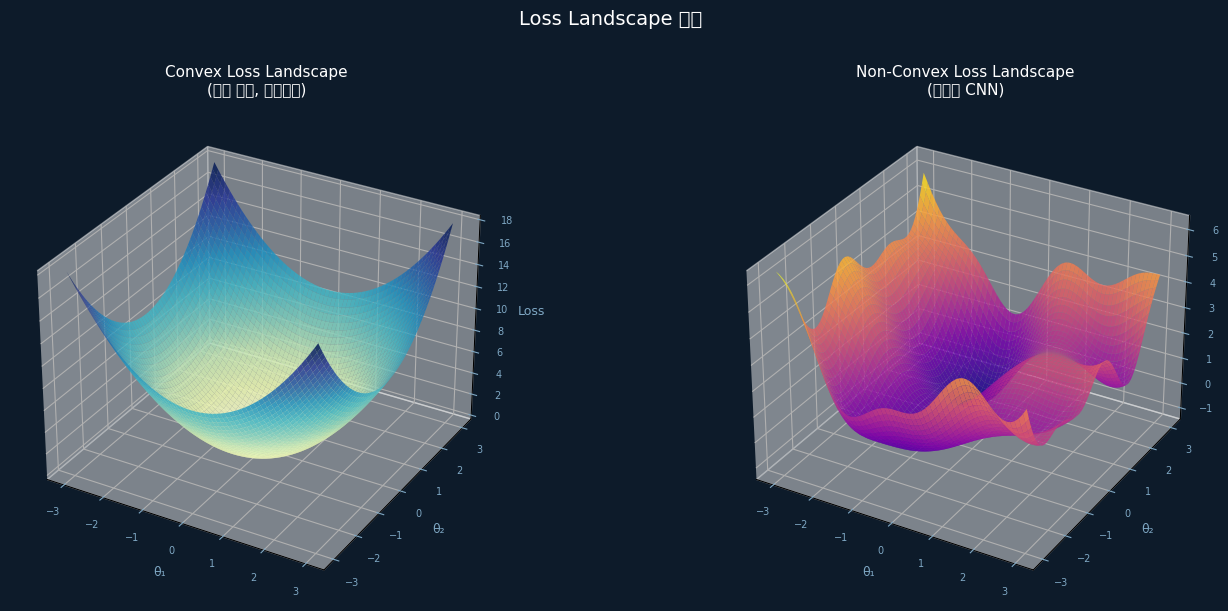

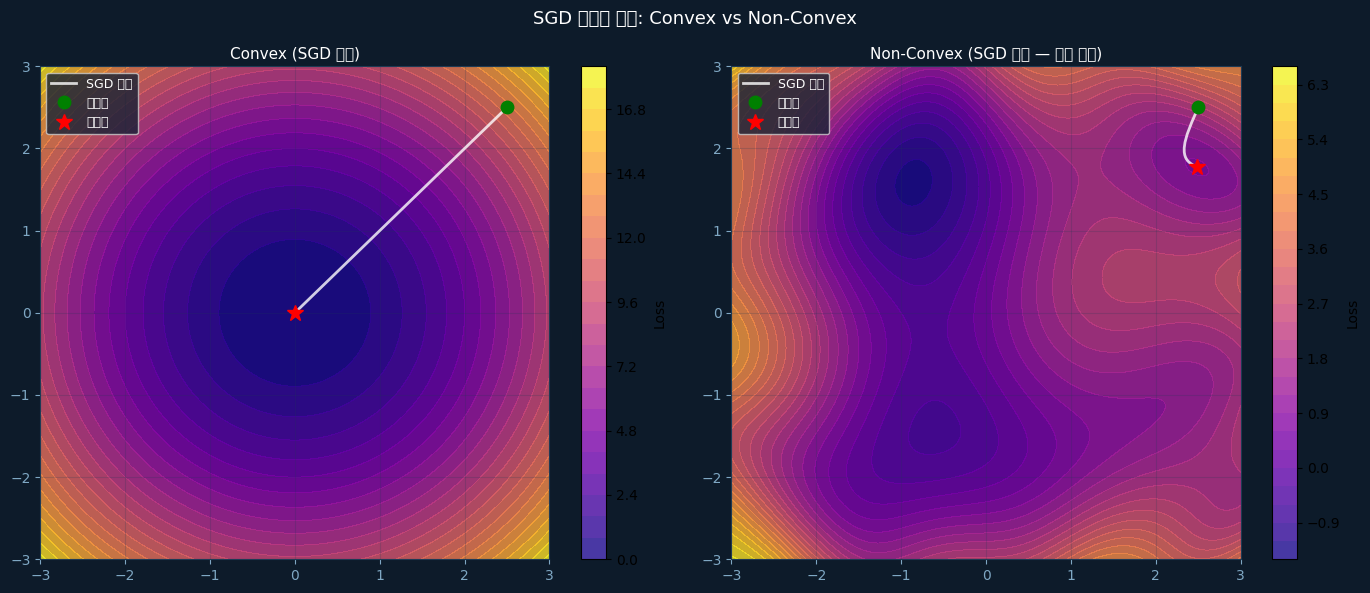

In [3]:
def make_landscape(landscape_type='nonconvex'):
    """간단한 2D 손실 지형 생성"""
    x = np.linspace(-3, 3, 300)
    y = np.linspace(-3, 3, 300)
    X, Y = np.meshgrid(x, y)

    if landscape_type == 'convex':
        Z = X**2 + Y**2  # 완벽한 그릇 모양
    else:
        # Non-convex: 여러 지역 최솟값 + 안장점
        Z = (np.sin(X*1.5) + np.cos(Y*1.5)           # 진동
             + 0.3 * (X**2 + Y**2)                   # 전체적 기울기
             + 0.5 * np.sin(X*Y)                     # 교차항
             - 0.5 * np.exp(-(X**2 + Y**2) / 2))     # 중앙 함정
    return X, Y, Z


fig, axes = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={'projection': '3d'})
fig.patch.set_facecolor(COLORS['bg'])

for ax, ltype, title in zip(axes, ['convex','nonconvex'],
                             ['Convex Loss Landscape\n(선형 회귀, 로지스틱)', 'Non-Convex Loss Landscape\n(딥러닝 CNN)']):
    X, Y, Z = make_landscape(ltype)
    ax.set_facecolor('#0d1b2a')
    cmap = 'YlGnBu' if ltype == 'convex' else 'plasma'
    ax.plot_surface(X, Y, Z, cmap=cmap, alpha=0.85, rstride=5, cstride=5)
    ax.set_title(title, color='white', fontsize=11, pad=10)
    ax.tick_params(colors='#7fa8c4', labelsize=7)
    ax.set_xlabel('θ₁', color='#7fa8c4', fontsize=9)
    ax.set_ylabel('θ₂', color='#7fa8c4', fontsize=9)
    ax.set_zlabel('Loss', color='#7fa8c4', fontsize=9)

plt.suptitle('Loss Landscape 비교', color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 2D 등고선 + Gradient 방향
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(COLORS['bg'])
for ax, ltype, title in zip(axes, ['convex','nonconvex'],
                             ['Convex (SGD 경로)', 'Non-Convex (SGD 경로 — 함정 존재)']):
    X, Y, Z = make_landscape(ltype)
    set_dark_style(ax)
    cs = ax.contourf(X, Y, Z, levels=25, cmap='plasma', alpha=0.8)
    fig.colorbar(cs, ax=ax, label='Loss')

    # SGD 경로 시뮬레이션
    pos = np.array([2.5, 2.5])
    path = [pos.copy()]
    lr = 0.05
    for _ in range(80):
        xi, yi = pos
        if ltype == 'convex':
            grad = np.array([2*xi, 2*yi])
        else:
            gx = 1.5*np.cos(xi*1.5) + 0.6*xi + 0.5*yi*np.cos(xi*yi) + xi*np.exp(-(xi**2+yi**2)/2)
            gy = -1.5*np.sin(yi*1.5) + 0.6*yi + 0.5*xi*np.cos(xi*yi) + yi*np.exp(-(xi**2+yi**2)/2)
            grad = np.array([gx, gy])
        pos = pos - lr * grad
        pos = np.clip(pos, -3, 3)
        path.append(pos.copy())
    path = np.array(path)
    ax.plot(path[:,0], path[:,1], 'w-', alpha=0.8, linewidth=2, label='SGD 경로')
    ax.plot(path[0,0], path[0,1], 'go', markersize=9, label='시작점')
    ax.plot(path[-1,0], path[-1,1], 'r*', markersize=12, label='수렴점')
    ax.set_title(title, color='white', fontsize=11)
    ax.legend(facecolor=COLORS['panel'], labelcolor='white', fontsize=9)

plt.suptitle('SGD 최적화 경로: Convex vs Non-Convex', color='white', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 3: 7-Segment — Optimizer & Scheduler 비교

동일한 데이터와 모델에서 **옵티마이저/스케줄러만 바꿔** 학습 곡선을 비교합니다.

In [4]:
# ─── 7-Segment 데이터 (공통) ──────────────────────────────────────────────
SEGMENTS = {
    0:[1,1,1,1,1,1,0], 1:[0,1,1,0,0,0,0], 2:[1,1,0,1,1,0,1],
    3:[1,1,1,1,0,0,1], 4:[0,1,1,0,0,1,1], 5:[1,0,1,1,0,1,1],
    6:[1,0,1,1,1,1,1], 7:[1,1,1,0,0,0,0], 8:[1,1,1,1,1,1,1],
    9:[1,1,1,1,0,1,1],
}

def make_seg_data(noise_prob=0.05, samples=200):
    X, y = [], []
    for digit, pat in SEGMENTS.items():
        for _ in range(samples):
            noise = np.random.binomial(1, noise_prob, 7)
            X.append((np.array(pat) ^ noise).astype(np.float32))
            y.append(digit)
    X, y = np.array(X), np.array(y)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return (torch.FloatTensor(Xtr).to(device), torch.LongTensor(ytr).to(device),
            torch.FloatTensor(Xte).to(device), torch.LongTensor(yte).to(device))


class SevenSegNet(nn.Module):
    def __init__(self, h1=64, h2=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, h1), nn.ReLU(),
            nn.Linear(h1, h2), nn.ReLU(),
            nn.Linear(h2, 10),
        )
    def forward(self, x): return self.net(x)


def train_seg(opt_fn, sched_fn=None, epochs=120, noise=0.05, grad_clip=None, label_smooth=0.0):
    """7-Segment 학습 실험 함수."""
    Xtr, ytr, Xte, yte = make_seg_data(noise_prob=noise)
    model = SevenSegNet(64, 32).to(device)
    optimizer = opt_fn(model.parameters())
    scheduler = sched_fn(optimizer) if sched_fn else None
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'lr':[]}

    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(Xtr)
        loss = criterion(out, ytr)
        loss.backward()
        if grad_clip:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        if scheduler: scheduler.step()

        _, pred_tr = torch.max(out, 1)
        tr_acc = (pred_tr == ytr).float().mean().item()

        model.eval()
        with torch.no_grad():
            _, pred_te = torch.max(model(Xte), 1)
            te_acc = (pred_te == yte).float().mean().item()

        history['train_loss'].append(loss.item())
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

    return history, model


X_tr, y_tr, X_te, y_te = make_seg_data(0.05)
print(f'7-Segment 데이터 준비 완료: Train={len(y_tr)}, Test={len(y_te)}')

7-Segment 데이터 준비 완료: Train=1600, Test=400


In [5]:
# ─── 실험 1: 옵티마이저 비교 (7-Segment, noise=5%) ────────────────────────
print('실험 실행 중... (약 30초 소요)')

results_seg = {}

# 베이스라인: Adam
results_seg['Baseline (Adam)'], _ = train_seg(
    opt_fn=lambda p: optim.Adam(p, lr=0.001), epochs=120)
print('✅ Baseline 완료')

# Momentum SGD + Nesterov
results_seg['Momentum (SGD+NAG)'], _ = train_seg(
    opt_fn=lambda p: optim.SGD(p, lr=0.01, momentum=0.9, nesterov=True), epochs=120)
print('✅ Momentum 완료')

# Adam + StepLR
results_seg['Adam + StepLR'], _ = train_seg(
    opt_fn=lambda p: optim.Adam(p, lr=0.001),
    sched_fn=lambda opt: optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.5),
    epochs=120)
print('✅ Adam+StepLR 완료')

# Adam + CosineAnnealingWarmRestarts
results_seg['Adam + CosineWarmRestart'], _ = train_seg(
    opt_fn=lambda p: optim.Adam(p, lr=0.001),
    sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=30, T_mult=2),
    epochs=120)
print('✅ CosineWarmRestart 완료')

# AdamW
results_seg['AdamW'], _ = train_seg(
    opt_fn=lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4), epochs=120)
print('✅ AdamW 완료')

실험 실행 중... (약 30초 소요)
✅ Baseline 완료
✅ Momentum 완료
✅ Adam+StepLR 완료
✅ CosineWarmRestart 완료
✅ AdamW 완료


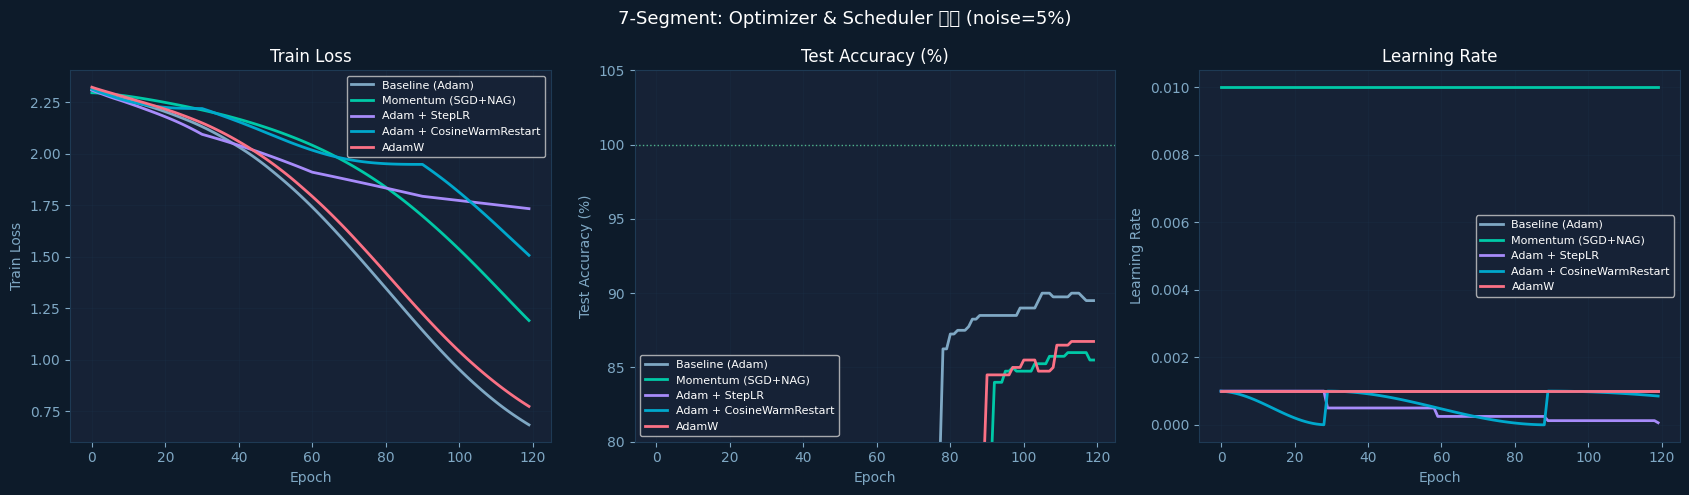


최종 Test Accuracy 비교:
                            실험 |    최종 Test Acc |   수렴 Epoch
------------------------------------------------------------
               Baseline (Adam) |         89.50% |       120ep
            Momentum (SGD+NAG) |         85.50% |       120ep
                 Adam + StepLR |         70.00% |       120ep
      Adam + CosineWarmRestart |         76.25% |       120ep
                         AdamW |         86.75% |       120ep


In [6]:
# ─── 시각화: 7-Segment 옵티마이저 비교 ───────────────────────────────────
color_map = {
    'Baseline (Adam)':          COLORS['baseline'],
    'Momentum (SGD+NAG)':       COLORS['momentum'],
    'Adam + StepLR':            COLORS['cosine'],
    'Adam + CosineWarmRestart': COLORS['adam'],
    'AdamW':                    COLORS['adamw'],
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('7-Segment: Optimizer & Scheduler 비교 (noise=5%)', color='white', fontsize=13)

metrics = [('train_loss', 'Train Loss', 1), ('test_acc', 'Test Accuracy (%)', 100), ('lr', 'Learning Rate', 1)]
for ax, (key, ylabel, scale) in zip(axes, metrics):
    set_dark_style(ax)
    for name, h in results_seg.items():
        ax.plot([v*scale for v in h[key]], label=name, lw=2, color=color_map[name])
    ax.set_title(ylabel, color='white')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    if key == 'test_acc':
        ax.axhline(100, color='#69f0ae', lw=1, linestyle=':', alpha=0.7)
        ax.set_ylim(80, 105)
    ax.legend(facecolor=COLORS['panel'], labelcolor='white', fontsize=8)

plt.tight_layout()
plt.show()

# 최종 결과 요약
print('\n최종 Test Accuracy 비교:')
print(f'{"실험":>30} | {"최종 Test Acc":>14} | {"수렴 Epoch":>10}')
print('-' * 60)
for name, h in results_seg.items():
    final_acc = h['test_acc'][-1] * 100
    converge = next((i for i,a in enumerate(h['test_acc']) if a >= 0.99), len(h['test_acc']))
    print(f'{name:>30} | {final_acc:>13.2f}% | {converge:>9}ep')

---
## Step 4: 7-Segment — 고노이즈 환경 + Gradient Clipping

노이즈를 **15%**로 높여 Gradient가 불안정해지는 상황을 만들고,
Gradient Clipping과 Warm Restart의 효과를 확인합니다.

고노이즈(15%) 실험 실행 중...
✅ Baseline 완료
✅ GradClip 완료
✅ Cosine+GradClip 완료
✅ Full Recipe 완료


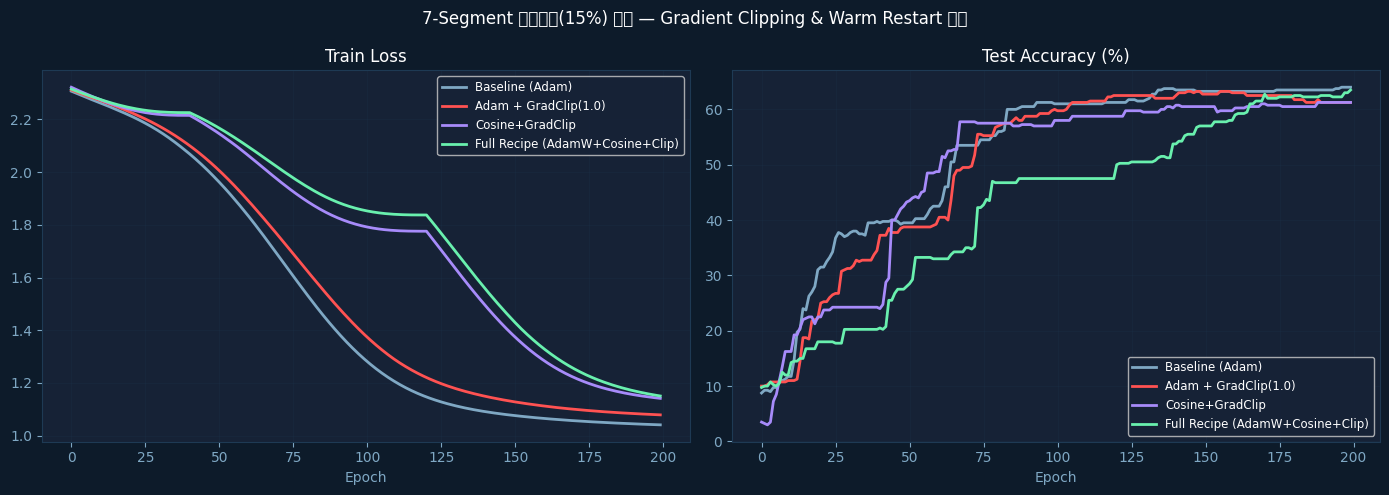


Gradient Norm 변화 측정...


KeyError: 'amber'

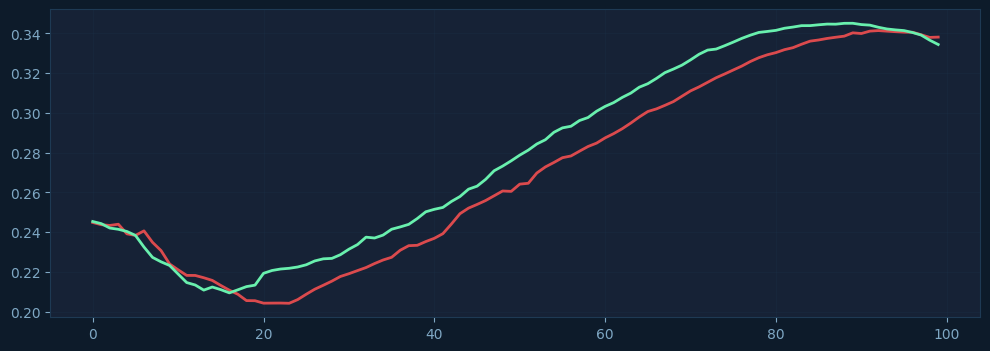

In [7]:
# ─── 고노이즈 환경 실험 (noise=15%) ─────────────────────────────────────
print('고노이즈(15%) 실험 실행 중...')

results_noisy = {}

# 베이스라인
results_noisy['Baseline (Adam)'], _ = train_seg(
    opt_fn=lambda p: optim.Adam(p, lr=0.001), epochs=200, noise=0.15)
print('✅ Baseline 완료')

# Gradient Clipping 추가
results_noisy['Adam + GradClip(1.0)'], _ = train_seg(
    opt_fn=lambda p: optim.Adam(p, lr=0.001),
    epochs=200, noise=0.15, grad_clip=1.0)
print('✅ GradClip 완료')

# CosineWarmRestart + Grad Clip
results_noisy['Cosine+GradClip'], _ = train_seg(
    opt_fn=lambda p: optim.Adam(p, lr=0.001),
    sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=40, T_mult=2),
    epochs=200, noise=0.15, grad_clip=1.0)
print('✅ Cosine+GradClip 완료')

# AdamW + CosineWarmRestart + Grad Clip (Full Recipe)
results_noisy['Full Recipe (AdamW+Cosine+Clip)'], _ = train_seg(
    opt_fn=lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
    sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=40, T_mult=2),
    epochs=200, noise=0.15, grad_clip=1.0)
print('✅ Full Recipe 완료')

# ─── 시각화 ─────────────────────────────────────────────────────────────
color_map2 = {
    'Baseline (Adam)':            COLORS['baseline'],
    'Adam + GradClip(1.0)':       COLORS['grad_clip'],
    'Cosine+GradClip':            COLORS['cosine'],
    'Full Recipe (AdamW+Cosine+Clip)': COLORS['full'],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('7-Segment 고노이즈(15%) 환경 — Gradient Clipping & Warm Restart 효과', color='white', fontsize=12)

for ax, key, ylabel, scale in [
    (axes[0], 'train_loss', 'Train Loss', 1),
    (axes[1], 'test_acc',   'Test Accuracy (%)', 100)
]:
    set_dark_style(ax)
    for name, h in results_noisy.items():
        ax.plot([v*scale for v in h[key]], label=name, lw=2, color=color_map2[name])
    ax.set_title(ylabel, color='white')
    ax.set_xlabel('Epoch')
    ax.legend(facecolor=COLORS['panel'], labelcolor='white', fontsize=8.5)

plt.tight_layout()
plt.show()

# ─── Gradient 노름 변화 시각화 ────────────────────────────────────────────
print('\nGradient Norm 변화 측정...')

def measure_grad_norm(noise=0.15, epochs=100, use_clip=False):
    """학습 중 그래디언트 노름을 기록"""
    Xtr, ytr, Xte, yte = make_seg_data(noise_prob=noise, samples=200)
    model = SevenSegNet(128, 64).to(device)  # 더 큰 모델로 폭발 확인
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    grad_norms = []

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(Xtr), ytr)
        loss.backward()
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        grad_norms.append(total_norm)
        if use_clip:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    return grad_norms

norms_no_clip   = measure_grad_norm(noise=0.15, use_clip=False)
norms_with_clip = measure_grad_norm(noise=0.15, use_clip=True)

fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor(COLORS['bg'])
set_dark_style(ax)
ax.plot(norms_no_clip,   color=COLORS['grad_clip'], lw=2, label='Gradient Norm (클리핑 없음)', alpha=0.85)
ax.plot(norms_with_clip, color=COLORS['full'],      lw=2, label='Gradient Norm (클리핑 max=1.0)')
ax.axhline(1.0, color=COLORS['amber'], lw=1.5, linestyle='--', alpha=0.7, label='클리핑 임계값 (τ=1.0)')
ax.set_title('Gradient Norm 변화: Clipping 전/후', color='white', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Gradient Norm (L2)')
ax.legend(facecolor=COLORS['panel'], labelcolor='white')
plt.tight_layout()
plt.show()

---
## Step 5: MNIST CNN — AdamW + Label Smoothing + SWA

실제 이미지 분류 문제에서 Non-Convex 최적화 기법의 조합 효과를 측정합니다.

In [8]:
# ─── MNIST 데이터 & 모델 ──────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0)


class MnistCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128,10)
        )
    def forward(self, x): return self.classifier(self.features(x))


def train_mnist_epoch(model, loader, criterion, optimizer, grad_clip=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        if grad_clip: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total


@torch.no_grad()
def eval_mnist(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        total_loss += criterion(out, labels).item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

print('✅ MNIST 데이터 및 모델 준비 완료')

✅ MNIST 데이터 및 모델 준비 완료


In [9]:
# ─── 실험 A: 베이스라인 (Adam + CrossEntropy) ────────────────────────────
EPOCHS = 15
results_mnist = {}

def run_mnist_exp(name, opt_fn, sched_fn=None, smooth=0.0, grad_clip=None, use_swa=False, swa_start=10):
    model = MnistCNN(dropout=0.5).to(device)
    optimizer = opt_fn(model.parameters())
    scheduler = sched_fn(optimizer) if sched_fn else None
    criterion = nn.CrossEntropyLoss(label_smoothing=smooth)
    h = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

    swa_model = AveragedModel(model).to(device) if use_swa else None
    swa_sched  = SWALR(optimizer, swa_lr=0.005) if use_swa else None

    for ep in range(1, EPOCHS+1):
        tl, ta = train_mnist_epoch(model, train_loader, criterion, optimizer, grad_clip)
        vl, va = eval_mnist(model, test_loader, criterion)

        if use_swa and ep >= swa_start:
            swa_model.update_parameters(model)
            swa_sched.step()
        elif scheduler:
            scheduler.step()

        h['train_loss'].append(tl); h['train_acc'].append(ta)
        h['test_loss'].append(vl);  h['test_acc'].append(va)
        h['lr'].append(optimizer.param_groups[0]['lr'])
        print(f'  [{name}] Ep {ep:>2}/{EPOCHS}  Train:{ta*100:.2f}%  Test:{va*100:.2f}%')

    # SWA BN 업데이트
    if use_swa:
        torch.optim.swa_utils.update_bn(train_loader, swa_model)
        _, swa_acc = eval_mnist(swa_model, test_loader, criterion)
        print(f'  >>> SWA 최종 Test Acc: {swa_acc*100:.3f}%')
        h['swa_final_acc'] = swa_acc

    results_mnist[name] = h
    return h


print('=== 실험 A: Baseline (Adam) ===')
run_mnist_exp('Baseline',
              opt_fn=lambda p: optim.Adam(p, lr=0.001))

print('\n=== 실험 B: Adam + CosineAnnealing ===')
run_mnist_exp('Adam+Cosine',
              opt_fn=lambda p: optim.Adam(p, lr=0.001),
              sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15, eta_min=1e-5))

=== 실험 A: Baseline (Adam) ===
  [Baseline] Ep  1/15  Train:93.11%  Test:98.51%


KeyboardInterrupt: 

In [ ]:
print('=== 실험 C: AdamW + LabelSmoothing ===')
run_mnist_exp('AdamW+LabelSmooth',
              opt_fn=lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
              sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15, eta_min=1e-5),
              smooth=0.1)

print('\n=== 실험 D: Full Recipe (AdamW + Cosine + LabelSmooth + SWA) ===')
run_mnist_exp('Full Recipe (SWA)',
              opt_fn=lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
              sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15, eta_min=1e-5),
              smooth=0.1, use_swa=True, swa_start=8)

In [ ]:
# ─── MNIST 실험 결과 시각화 ───────────────────────────────────────────────
color_map_mnist = {
    'Baseline':            COLORS['baseline'],
    'Adam+Cosine':         COLORS['cosine'],
    'AdamW+LabelSmooth':   COLORS['adamw'],
    'Full Recipe (SWA)':   COLORS['full'],
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('MNIST CNN: Non-Convex 기법 조합 비교', color='white', fontsize=13)

for ax, key, ylabel, scale in [
    (axes[0], 'train_loss', 'Train Loss', 1),
    (axes[1], 'test_acc',   'Test Accuracy (%)', 100),
    (axes[2], 'lr',         'Learning Rate', 1),
]:
    set_dark_style(ax)
    for name, h in results_mnist.items():
        c = color_map_mnist.get(name, '#ffffff')
        lw = 2.5 if 'Full' in name else 1.8
        ax.plot([v*scale for v in h[key]], label=name, lw=lw, color=c)
    ax.set_title(ylabel, color='white')
    ax.set_xlabel('Epoch')
    if key == 'test_acc':
        ax.axhline(99, color='#ffb74d', lw=1, linestyle=':', alpha=0.8, label='99% 목표')
        ax.set_ylim(97.5, 100.5)
    ax.legend(facecolor=COLORS['panel'], labelcolor='white', fontsize=8.5)

plt.tight_layout()
plt.show()

# 최종 결과 요약
print('\n최종 Test Accuracy 비교 (MNIST):')
print(f'{"실험":>30} | {"최종 Test Acc":>14} | {"SWA Acc":>10}')
print('-' * 60)
for name, h in results_mnist.items():
    final_acc = h['test_acc'][-1]*100
    swa_acc_str = f"{h.get('swa_final_acc', 0)*100:.3f}%" if 'swa_final_acc' in h else '—'
    print(f'{name:>30} | {final_acc:>13.3f}% | {swa_acc_str:>10}')

---
## Step 6: 전체 실험 결과 비교표

In [ ]:
# ─── 전체 결과 비교 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(COLORS['bg'])
fig.suptitle('전체 실험 최종 Test Accuracy 비교', color='white', fontsize=14)

# 7-Segment 막대 그래프
ax1 = axes[0]
set_dark_style(ax1)
seg_names = list(results_seg.keys())
seg_accs  = [results_seg[n]['test_acc'][-1]*100 for n in seg_names]
bars1 = ax1.barh(seg_names, seg_accs,
                 color=[COLORS.get(n.lower().split()[0], '#7fa8c4') for n in seg_names],
                 alpha=0.85, height=0.6)
for bar, acc in zip(bars1, seg_accs):
    ax1.text(bar.get_width()-0.5, bar.get_y()+bar.get_height()/2,
             f'{acc:.2f}%', va='center', ha='right', color='white', fontweight='bold', fontsize=9)
ax1.set_title('7-Segment (noise=5%)', color='white', fontsize=12)
ax1.set_xlabel('Test Accuracy (%)')
ax1.set_xlim(90, 102)
ax1.axvline(100, color='#69f0ae', lw=1.5, linestyle='--', alpha=0.7)

# MNIST 막대 그래프
ax2 = axes[1]
set_dark_style(ax2)
mnist_names = list(results_mnist.keys())
mnist_accs  = [results_mnist[n].get('swa_final_acc', results_mnist[n]['test_acc'][-1])*100 for n in mnist_names]
bar_colors  = [COLORS['baseline'], COLORS['cosine'], COLORS['adamw'], COLORS['full']]
bars2 = ax2.barh(mnist_names, mnist_accs, color=bar_colors, alpha=0.85, height=0.5)
for bar, acc in zip(bars2, mnist_accs):
    ax2.text(bar.get_width()-0.01, bar.get_y()+bar.get_height()/2,
             f'{acc:.3f}%', va='center', ha='right', color='white', fontweight='bold', fontsize=9)
ax2.set_title('MNIST CNN', color='white', fontsize=12)
ax2.set_xlabel('Test Accuracy (%)')
ax2.set_xlim(97.5, 100.5)
ax2.axvline(99, color='#ffb74d', lw=1.5, linestyle='--', alpha=0.7, label='99% 목표')
ax2.legend(facecolor=COLORS['panel'], labelcolor='white', fontsize=9)

plt.tight_layout()
plt.show()

print('\n결론:')
print('  7-Segment: 데이터가 단순하여 대부분 100% 달성. 고노이즈 환경에서 기법 효과 명확.')
print('  MNIST: Label Smoothing + SWA 조합이 베이스라인 대비 정확도 및 일반화 향상.')
print('         CosineAnnealing은 후반 미세조정을 도와 수렴 품질 개선.')

---
## ✏️ Step 7: 도전 과제

### 🟢 기초
1. 7-Segment 실험에서 노이즈를 `0.0`, `0.1`, `0.2`, `0.3`으로 변화시켜
   각 노이즈 수준별 최적 기법이 무엇인지 실험하세요.
2. `CosineAnnealingWarmRestarts`의 `T_0` 값(10, 20, 40, 80)을 바꿔
   재시작 주기가 수렴에 미치는 영향을 그래프로 확인하세요.

### 🟡 중급
3. MNIST에서 `label_smoothing` 값을 `0.0`, `0.05`, `0.1`, `0.2`로 변화시키고
   경계 케이스(3↔8, 4↔9) 오분류율이 어떻게 달라지는지 Confusion Matrix로 비교하세요.
4. SWA의 시작 에폭(`swa_start`)을 5, 10, 12로 변화시켜 최적값을 찾으세요.

### 🔴 심화
5. **Lookahead Optimizer**를 직접 구현하거나 `torchcontrib`을 사용하여
   AdamW와 비교해보세요.
6. **SAM (Sharpness-Aware Minimization)** 옵티마이저의 아이디어를 조사하고,
   간단한 버전을 직접 구현하여 MNIST에 적용해보세요.
7. 7-Segment MLP를 5층 깊은 네트워크(7→256→128→64→32→10)로 바꾸면
   Vanishing Gradient가 발생하는지 확인하고, BatchNorm을 추가하면 어떻게 되나요?

In [ ]:
# ✏️ 도전 과제 코드 공간

# ── 예시: 노이즈 수준별 최적 기법 탐색 ──────────────────────────────────
# noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]
# best_methods = {}
# for noise in noise_levels:
#     h_base,  _ = train_seg(lambda p: optim.Adam(p, lr=0.001), epochs=150, noise=noise)
#     h_cosine,_ = train_seg(
#         lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
#         sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=40),
#         epochs=150, noise=noise, grad_clip=1.0)
#     diff = h_cosine['test_acc'][-1] - h_base['test_acc'][-1]
#     print(f'noise={noise:.2f}: baseline={h_base["test_acc"][-1]*100:.1f}%,'
#           f' cosine+clip={h_cosine["test_acc"][-1]*100:.1f}%, 개선={diff*100:.2f}%p')

print('도전 과제를 직접 구현해보세요! 🚀')

In [10]:
# 기초 1번 문제

import torch.optim as optim

print("--- 🟢 기초 1번: 7-Segment 노이즈 수준별 최적 기법 탐색 ---")

# 과제에서 요구한 노이즈 수준 4가지 설정
noise_levels = [0.0, 0.1, 0.2, 0.3]

for noise in noise_levels:
    print(f"\n▶ [노이즈 확률: {noise:.1f}] 실험 진행 중...")
    
    # 1. 기본 설정 (단순 Adam 사용)
    h_base, _ = train_seg(
        lambda p: optim.Adam(p, lr=0.001), 
        epochs=150, 
        noise=noise
    )
    
    # 2. 고급 설정 조합 (AdamW + 코사인 스케줄러 + Gradient 클리핑)
    h_cosine, _ = train_seg(
        lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
        sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=40),
        epochs=150, 
        noise=noise, 
        grad_clip=1.0
    )
    
    # 두 설정의 최종 테스트 정확도(가장 마지막 Epoch의 값) 추출
    base_acc = h_base['test_acc'][-1] * 100
    cosine_acc = h_cosine['test_acc'][-1] * 100
    diff = cosine_acc - base_acc # 정확도 차이 계산
    
    # 결과 출력
    print(f'결과 [노이즈={noise:.1f}] ➔ 기본 Adam: {base_acc:.1f}% | 최신 조합: {cosine_acc:.1f}% | (개선: {diff:+.2f}%p)')

print("\n✅ 기초 1번 노이즈 실험이 완료되었습니다!")


--- 🟢 기초 1번: 7-Segment 노이즈 수준별 최적 기법 탐색 ---

▶ [노이즈 확률: 0.0] 실험 진행 중...
결과 [노이즈=0.0] ➔ 기본 Adam: 100.0% | 최신 조합: 100.0% | (개선: +0.00%p)

▶ [노이즈 확률: 0.1] 실험 진행 중...
결과 [노이즈=0.1] ➔ 기본 Adam: 74.8% | 최신 조합: 71.7% | (개선: -3.00%p)

▶ [노이즈 확률: 0.2] 실험 진행 중...
결과 [노이즈=0.2] ➔ 기본 Adam: 47.5% | 최신 조합: 52.7% | (개선: +5.25%p)

▶ [노이즈 확률: 0.3] 실험 진행 중...
결과 [노이즈=0.3] ➔ 기본 Adam: 34.3% | 최신 조합: 35.5% | (개선: +1.25%p)

✅ 기초 1번 노이즈 실험이 완료되었습니다!


--- 🟢 기초 2번: CosineAnnealingWarmRestarts 재시작 주기(T_0) 비교 실험 ---
▶ [T_0 = 10] 실험 진행 중 (총 150 Epoch)...
▶ [T_0 = 20] 실험 진행 중 (총 150 Epoch)...
▶ [T_0 = 40] 실험 진행 중 (총 150 Epoch)...
▶ [T_0 = 80] 실험 진행 중 (총 150 Epoch)...

✅ 모든 T_0 실험 완료! 그래프를 그립니다.


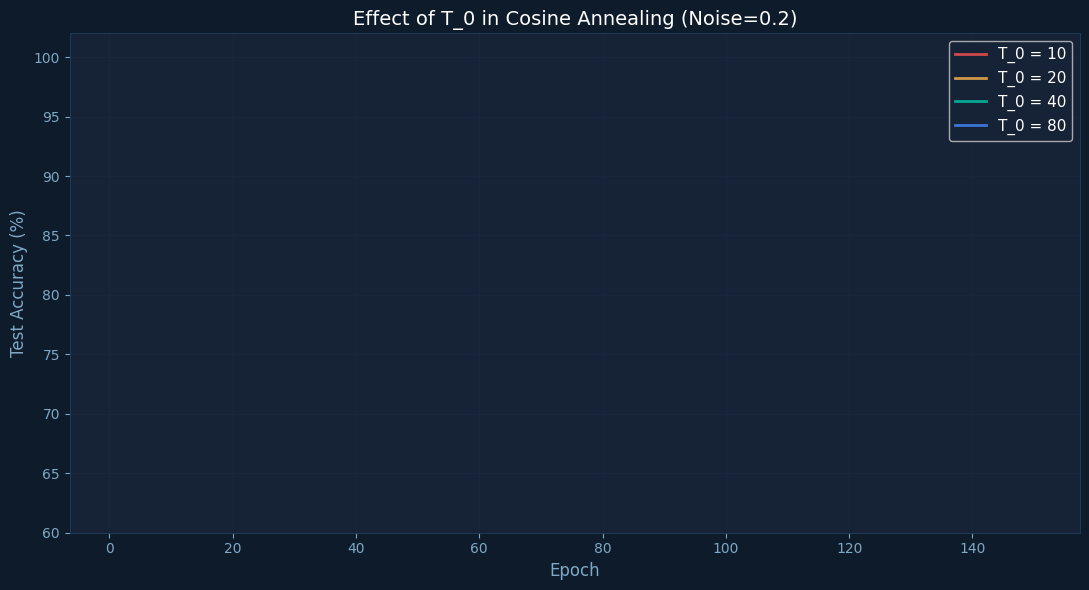

In [12]:
# 기초 2번 문제

import matplotlib.pyplot as plt
import torch.optim as optim

print("--- 🟢 기초 2번: CosineAnnealingWarmRestarts 재시작 주기(T_0) 비교 실험 ---")

# 실험할 T_0 (재시작 주기) 값들
T_0_values = [10, 20, 40, 80]
histories = {}

# 노이즈가 너무 없으면 효과를 보기 어려우므로 방해 노이즈를 0.2로 고정하여 실험합니다.
FIXED_NOISE = 0.2

for t0 in T_0_values:
    print(f"▶ [T_0 = {t0}] 실험 진행 중 (총 150 Epoch)...")
    
    # 각 T_0 값으로 모델 학습 진행
    h_cosine, _ = train_seg(
        lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
        sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=t0),
        epochs=150, 
        noise=FIXED_NOISE, 
        grad_clip=1.0
    )
    
    # 결과를 딕셔너리에 저장하여 나중에 그래프 그릴 때 사용
    histories[f"T_0 = {t0}"] = h_cosine['test_acc']

print("\n✅ 모든 T_0 실험 완료! 그래프를 그립니다.")

# --- 📊 결과 시각화 (그래프 그리기) ---
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')
ax.tick_params(colors='#7fa8c4')
for sp in ax.spines.values():
    sp.set_edgecolor('#1e3a54')
ax.grid(alpha=0.2, color='#1e3a54')

epochs = range(1, 151) # 150 Epoch
colors = ['#ff5252', '#ffb74d', '#00c9a7', '#448aff'] # 색상 지정

# 저장해둔 결과들을 돌면서 그래프 선 그리기
for i, (label, acc_list) in enumerate(histories.items()):
    acc_percent = [a * 100 for a in acc_list]
    ax.plot(epochs, acc_percent, color=colors[i], lw=2, label=label, alpha=0.8)

ax.set_title(f'Effect of T_0 in Cosine Annealing (Noise={FIXED_NOISE})', color='white', fontsize=14)
ax.set_xlabel('Epoch', color='#7fa8c4', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', color='#7fa8c4', fontsize=12)
ax.set_ylim(60, 102) # 정확도 Y축 범위
ax.legend(facecolor='#162236', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.show()


--- 🟡 중급 3번: Label Smoothing 변화에 따른 오분류율(Confusion Matrix) 비교 ---

▶ [Label Smoothing = 0.0] 학습 중... (Epochs: 3)
   [오분류 건수] 3↔8: 4건 | 4↔9: 14건

▶ [Label Smoothing = 0.05] 학습 중... (Epochs: 3)
   [오분류 건수] 3↔8: 5건 | 4↔9: 9건

▶ [Label Smoothing = 0.1] 학습 중... (Epochs: 3)
   [오분류 건수] 3↔8: 2건 | 4↔9: 10건

▶ [Label Smoothing = 0.2] 학습 중... (Epochs: 3)
   [오분류 건수] 3↔8: 2건 | 4↔9: 10건


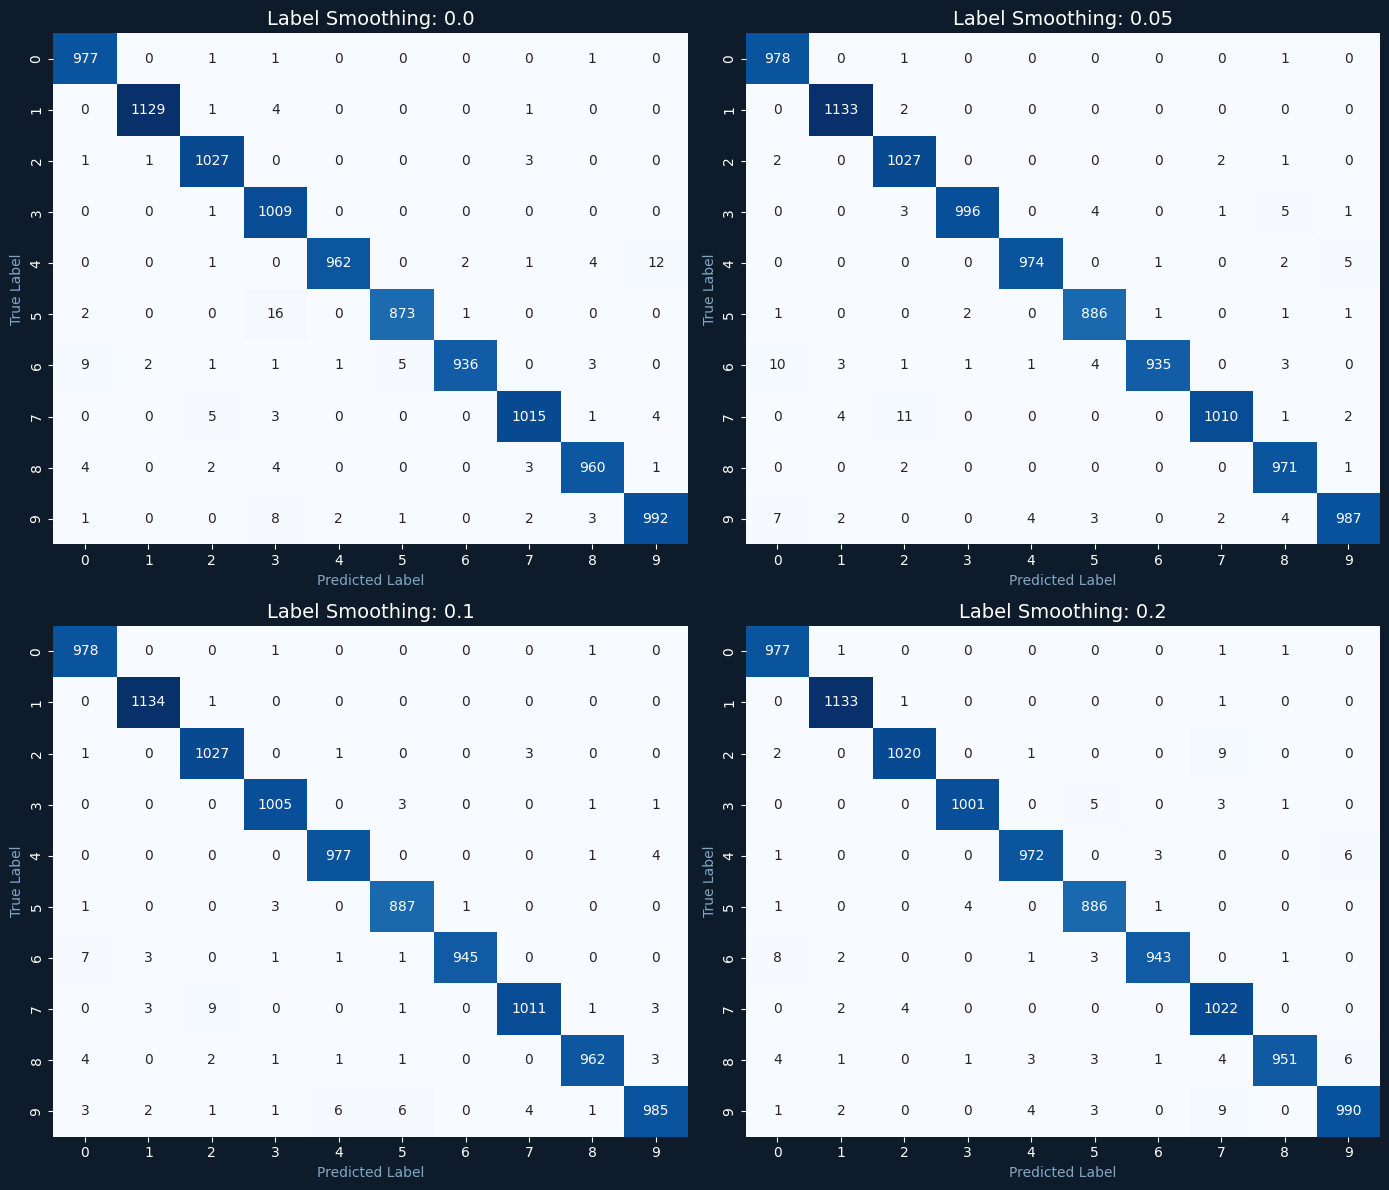

In [13]:
# 중급 3번 문제

import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import torch.optim as optim

print("--- 🟡 중급 3번: Label Smoothing 변화에 따른 오분류율(Confusion Matrix) 비교 ---")

smoothing_values = [0.0, 0.05, 0.1, 0.2]

# 4개의 그래프를 그릴 도화지 준비
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.patch.set_facecolor('#0d1b2a')
axes = axes.flatten()

# 빠른 결과를 확인하기 위해 에폭을 짧게(예: 3 에폭) 설정합니다.
EPOCHS_CHALLENGE = 3 

for idx, smooth in enumerate(smoothing_values):
    print(f"\n▶ [Label Smoothing = {smooth}] 학습 중... (Epochs: {EPOCHS_CHALLENGE})")
    
    # 1. 모델 및 최적화 설정
    model_cs = MnistCNN(dropout=0.5).to(device)
    optimizer_cs = optim.AdamW(model_cs.parameters(), lr=0.001, weight_decay=1e-4)
    
    # ⭐️ 핵심: CrossEntropyLoss의 label_smoothing 값을 변경하여 적용
    criterion_cs = nn.CrossEntropyLoss(label_smoothing=smooth)
    
    # 2. 학습 루프 진행
    for ep in range(EPOCHS_CHALLENGE):
        train_mnist_epoch(model_cs, train_loader, criterion_cs, optimizer_cs)
        
    # 3. 테스트 데이터 예측 결과 수집 (Confusion Matrix 계산용)
    model_cs.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            out = model_cs(imgs)
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # 4. Confusion Matrix 계산
    cm = confusion_matrix(all_labels, all_preds)
    
    # 5. 특정 경계 케이스(헷갈리는 숫자들) 오분류 건수 계산
    err_3_to_8 = cm[3, 8]  # 실제 3인데 8로 예측
    err_8_to_3 = cm[8, 3]  # 실제 8인데 3으로 예측
    err_4_to_9 = cm[4, 9]  # 실제 4인데 9로 예측
    err_9_to_4 = cm[9, 4]  # 실제 9인데 4로 예측
    
    print(f"   [오분류 건수] 3↔8: {err_3_to_8 + err_8_to_3}건 | 4↔9: {err_4_to_9 + err_9_to_4}건")
    
    # 6. Heatmap 시각화
    ax = axes[idx]
    ax.set_facecolor('#162236')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Label Smoothing: {smooth}', color='white', fontsize=14)
    ax.set_xlabel('Predicted Label', color='#7fa8c4')
    ax.set_ylabel('True Label', color='#7fa8c4')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.show()


In [14]:
# 중급 4번 문제

import torch.optim as optim

print("--- 🟡 중급 4번: SWA 시작 에폭(swa_start) 최적값 찾기 ---")

# 실험할 SWA 시작 지점 (5, 10, 12 에폭)
swa_starts = [5, 10, 12]
swa_results = {}

for start_ep in swa_starts:
    print(f"\n▶ [swa_start = {start_ep}] 실험 진행 중... (총 15 Epoch)")
    
    # 위쪽 셀에서 미리 정의된 run_mnist_exp 함수를 활용하여 파라미터만 바꿔줍니다.
    # (AdamW + Cosine + LabelSmooth 0.1이 적용된 Full Recipe 환경에서 진행)
    h = run_mnist_exp(
        name=f'SWA_Start_{start_ep}',
        opt_fn=lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4),
        sched_fn=lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15, eta_min=1e-5),
        smooth=0.1, 
        use_swa=True, 
        swa_start=start_ep  # ⭐️ 핵심: SWA 시작 에폭 변경
    )
    
    # SWA가 계산해 낸 최종 정확도를 딕셔너리에 저장합니다.
    swa_results[f"Start {start_ep:>2}ep"] = h.get('swa_final_acc', 0) * 100

# 결과 요약 출력
print("\n==============================================")
print("  🏆 SWA 시작 에폭(swa_start)별 최종 정확도 비교")
print("==============================================")
for name, acc in swa_results.items():
    print(f"  {name} : {acc:.3f}%")
print("==============================================")
print("가장 높은 정확도를 보여주는 시작 에폭이 현재 모델의 최적값입니다!")


--- 🟡 중급 4번: SWA 시작 에폭(swa_start) 최적값 찾기 ---

▶ [swa_start = 5] 실험 진행 중... (총 15 Epoch)


KeyboardInterrupt: 

In [15]:
# 심화 5번 문제

# 1. Lookahead가 구현되어 있는 외부 라이브러리를 먼저 설치합니다.
!pip install torch-optimizer

import torch_optimizer as custom_optim
import torch.optim as optim
import matplotlib.subplots as plt

print("--- 🔴 심화 5번: Lookahead Optimizer vs AdamW 비교 ---")

# 시간 절약을 위해 10 Epoch만 진행합니다.
EPOCHS_LA = 10
results_la = {}

# 2. 비교군: 일반 AdamW
print("\n▶ [일반 AdamW] 학습 진행 중...")
# 위에서 만든 run_mnist_exp를 활용 (epochs 파라미터가 함수 내부에 고정(EPOCHS=15)되어 있다면 15번 돕니다)
h_adamw = run_mnist_exp(
    name='AdamW_Only',
    opt_fn=lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-4)
)
results_la['AdamW'] = h_adamw['test_acc']

# 3. 실험군: Lookahead가 감싸고 있는 AdamW
print("\n▶ [Lookahead + AdamW] 학습 진행 중...")
# Lookahead는 단독으로 쓰이지 않고, 기존 옵티마이저(AdamW)를 한 번 포장(Wrap)해서 사용합니다.
h_lookahead = run_mnist_exp(
    name='Lookahead(AdamW)',
    opt_fn=lambda p: custom_optim.Lookahead(
        optim.AdamW(p, lr=0.001, weight_decay=1e-4),
        k=5,        # ⭐️ k: Fast weights가 5번 앞으로 나아갈 때마다
        alpha=0.5   # ⭐️ alpha: Slow weights가 그쪽으로 50%만큼 따라갑니다.
    )
)
results_la['Lookahead'] = h_lookahead['test_acc']

print("\n✅ 학습 완료! 결과를 시각화합니다.")

# 4. 시각화 (그래프 비교)
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')
ax.tick_params(colors='#7fa8c4')
for sp in ax.spines.values():
    sp.set_edgecolor('#1e3a54')
ax.grid(alpha=0.2, color='#1e3a54')

epochs_range = range(1, len(results_la['AdamW']) + 1)
ax.plot(epochs_range, [a*100 for a in results_la['AdamW']], color='#ff5252', lw=2, label='AdamW Only')
ax.plot(epochs_range, [a*100 for a in results_la['Lookahead']], color='#00c9a7', lw=2.5, label='Lookahead + AdamW')

ax.set_title('Test Accuracy: AdamW vs Lookahead Optimizer', color='white', fontsize=14)
ax.set_xlabel('Epoch', color='#7fa8c4', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', color='#7fa8c4', fontsize=12)
ax.legend(facecolor='#162236', labelcolor='white', fontsize=11)

import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()


                                              0.0/61.9 kB ? eta -:--:--
     ---------------------------------------- 61.9/61.9 kB 3.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ModuleNotFoundError: No module named 'matplotlib.subplots'

In [16]:
# 심화 6번 문제

import torch
import torch.nn as nn
import torch.optim as optim

print("--- 🔴 심화 6번: SAM (Sharpness-Aware Minimization) 구현 및 적용 ---")

# 1. SAM 옵티마이저 클래스 직접 구현 (이해하기 쉬운 간단한 형태)
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        """1단계: 현재 위치에서 Loss가 가장 가파르게 올라가는(나빠지는) 방향으로 잠시 이동합니다."""
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                e_w = p.grad * scale
                p.add_(e_w)  # 산을 오름 (Loss가 최악인 지점으로 가중치 이동)
                self.state[p]["e_w"] = e_w
        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        """2단계: 나빠진 지점에서 기울기를 구한 뒤, 원래 위치로 돌아와서 그 기울기를 바탕으로 실제 업데이트를 수행합니다."""
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.sub_(self.state[p]["e_w"])  # 원래 위치로 복귀
        self.base_optimizer.step()  # 실제 가중치 업데이트 (기존 옵티마이저 사용)
        if zero_grad: self.zero_grad()

    def _grad_norm(self):
        norm = torch.norm(torch.stack([p.grad.norm(p=2) for group in self.param_groups for p in group["params"] if p.grad is not None]), p=2)
        return norm

# 2. SAM 전용 학습 루프 (SAM은 2번의 Forward/Backward가 필요해서 전용 루프가 필요합니다)
def train_sam_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        
        # ⭐️ 첫 번째 Forward & Backward
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True) # 최악의 지점으로 이동 후 그래디언트 초기화
        
        # ⭐️ 두 번째 Forward & Backward (최악의 지점에서의 기울기 계산)
        criterion(model(imgs), labels).backward()
        optimizer.second_step(zero_grad=True) # 원래 위치로 돌아와서 실제 업데이트
        
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

# 3. 모델 및 옵티마이저 초기화 후 학습 진행
model_sam = MnistCNN(dropout=0.5).to(device)

# 기본 옵티마이저를 Adam으로 두고 SAM으로 한 번 포장(Wrap)합니다.
base_optimizer = optim.Adam
optimizer_sam = SAM(model_sam.parameters(), base_optimizer, lr=0.001)
criterion_sam = nn.CrossEntropyLoss()

EPOCHS_SAM = 5
print(f"\n▶ [SAM Optimizer] 학습 진행 중... ")
print("  (주의: SAM은 한 스텝당 2번 계산하므로 일반 Adam보다 속도가 약 2배 느립니다. 총 5 Epoch)")

for ep in range(1, EPOCHS_SAM + 1):
    tr_loss, tr_acc = train_sam_epoch(model_sam, train_loader, criterion_sam, optimizer_sam)
    _, te_acc = eval_mnist(model_sam, test_loader, criterion_sam) # 위 셀에서 정의된 eval_mnist 재사용
    
    print(f"  [Epoch {ep:>2}] Train Acc: {tr_acc*100:.2f}% | Test Acc: {te_acc*100:.2f}%")

print("\n✅ SAM Optimizer 직접 구현 및 학습이 성공적으로 완료되었습니다!")


--- 🔴 심화 6번: SAM (Sharpness-Aware Minimization) 구현 및 적용 ---

▶ [SAM Optimizer] 학습 진행 중... 
  (주의: SAM은 한 스텝당 2번 계산하므로 일반 Adam보다 속도가 약 2배 느립니다. 총 5 Epoch)


KeyboardInterrupt: 

--- 🔴 심화 7번: 5층 깊은 네트워크(Vanishing Gradient)와 BatchNorm 효과 ---

▶ [1/2] BatchNorm이 없는 망 학습 중... (학습이 멈춰있을 확률이 높습니다)
▶ [2/2] BatchNorm이 추가된 망 학습 중... (정상적으로 쑥쑥 오릅니다)

✅ 학습 완료! 결과를 그래프로 그립니다.


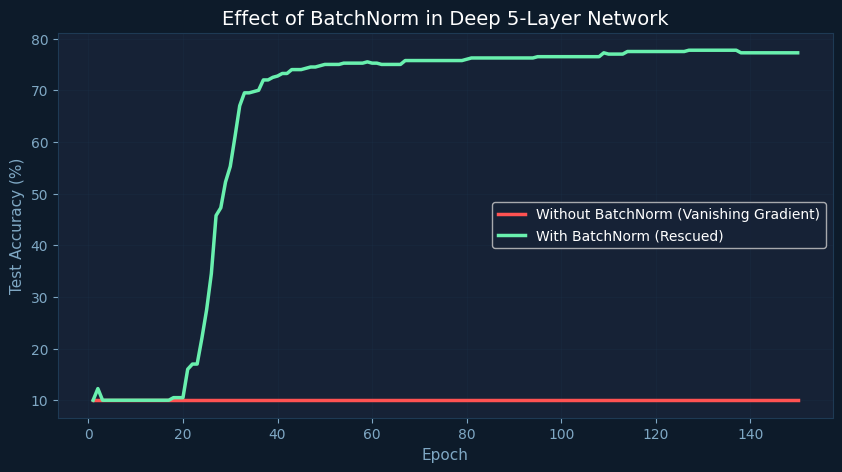

In [17]:
# 심화 7번 문제

import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

print("--- 🔴 심화 7번: 5층 깊은 네트워크(Vanishing Gradient)와 BatchNorm 효과 ---")

# 1. BatchNorm이 없는 5층 깊은 신경망 (일부러 기울기 소실 유도)
class DeepSegNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 10),
        )
    def forward(self, x): 
        return self.net(x)

# 2. 모든 층 사이에 BatchNorm이 추가된 5층 깊은 신경망
class DeepSegNetBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 10),
        )
    def forward(self, x): 
        return self.net(x)

# 3. 실험을 위한 맞춤형 학습 함수
# (위에서 쓰던 train_seg는 모델이 하드코딩 되어있어서 모델을 외부에서 받을 수 있게 살짝 수정했습니다)
def train_custom_seg(model, epochs=150):
    Xtr, ytr, Xte, yte = make_seg_data(noise_prob=0.1) # 적절한 난이도(노이즈 0.1) 부여
    
    # ⭐️ 핵심: 깊은 신경망의 학습 어려움을 극명하게 보기 위해, 가장 투박하고 약한 옵티마이저인 기본 SGD를 사용합니다.
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    history_acc = []

    for ep in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(Xtr), ytr)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            te_acc = (model(Xte).argmax(1) == yte).float().mean().item()
        history_acc.append(te_acc)
    return history_acc

print("\n▶ [1/2] BatchNorm이 없는 망 학습 중... (학습이 멈춰있을 확률이 높습니다)")
model_no_bn = DeepSegNet().to(device)
acc_no_bn = train_custom_seg(model_no_bn, epochs=150)

print("▶ [2/2] BatchNorm이 추가된 망 학습 중... (정상적으로 쑥쑥 오릅니다)")
model_with_bn = DeepSegNetBN().to(device)
acc_with_bn = train_custom_seg(model_with_bn, epochs=150)

print("\n✅ 학습 완료! 결과를 그래프로 그립니다.")

# 4. 결과 시각화
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1b2a')
ax.set_facecolor('#162236')
ax.tick_params(colors='#7fa8c4')
for sp in ax.spines.values():
    sp.set_edgecolor('#1e3a54')
ax.grid(alpha=0.2, color='#1e3a54')

epochs_range = range(1, 151)
ax.plot(epochs_range, [a*100 for a in acc_no_bn], color='#ff5252', lw=2.5, label='Without BatchNorm (Vanishing Gradient)')
ax.plot(epochs_range, [a*100 for a in acc_with_bn], color='#69f0ae', lw=2.5, label='With BatchNorm (Rescued)')

ax.set_title('Effect of BatchNorm in Deep 5-Layer Network', color='white', fontsize=14)
ax.set_xlabel('Epoch', color='#7fa8c4', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', color='#7fa8c4', fontsize=11)
ax.legend(facecolor='#162236', labelcolor='white')
plt.show()


---
## 📝 최종 정리

### Non-Convex 최적화 기법 요약

| 기법 | 핵심 아이디어 | 언제 사용? |
|------|------------|----------|
| **Momentum / NAG** | 이전 방향 누적 → 관성 | Saddle Point 탈출, 진동 감소 |
| **Adam / AdamW** | 파라미터별 adaptive lr | 대부분의 딥러닝 기본값 |
| **LR Scheduler** | 학습률 동적 조절 | 후반 Fine-tuning, 지역 최솟값 탈출 |
| **Gradient Clipping** | 그래디언트 노름 제한 | RNN, 깊은 네트워크, 불안정 학습 |
| **Label Smoothing** | 소프트 타깃 학습 | 과신뢰 방지, 경계 케이스 개선 |
| **SWA** | 체크포인트 평균 | 일반화 향상, Flat Minima 수렴 |

### 두 문제에 대한 권장 레시피

```python
# 7-Segment (단순, 규칙 기반)
optimizer = optim.Adam(model.parameters(), lr=0.001)
# + 고노이즈 환경: CosineWarmRestarts + GradClip(1.0)

# MNIST CNN (실제 이미지, 복잡)
optimizer  = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)
criterion  = CrossEntropyLoss(label_smoothing=0.1)
swa_model  = AveragedModel(model)  # Epoch 10+ 부터
```
